# Lab Assignment - 6

# Part A - Image Feature Extraction and Classification

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2

In [74]:
dataset_path = "Crack_and_NonCrack Images"

print(os.listdir(dataset_path))

['Cracks', 'NonCracks']


In [75]:
crack_path = os.path.join(dataset_path, "Cracks")
noncrack_path = os.path.join(dataset_path, "NonCracks")

print("Cracks:", len(os.listdir(crack_path)))
print("NonCracks:", len(os.listdir(noncrack_path)))

Cracks: 200
NonCracks: 200


In [76]:
print(os.listdir(crack_path)[:5])
print(os.listdir(noncrack_path)[:5])

['IMG_20180513_164959951_HDR resized_448.jpg', 'IMG_20180513_165129852_HDR resized_448.jpg', 'IMG_20180513_165150613_HDR resized_448.jpg', 'IMG_20180513_165345878_HDR resized_448.jpg', 'IMG_20180513_165349788_HDR resized_448.jpg']
['IMG_20180705_130729936 resized_448.jpg', 'IMG_20180705_130731751 resized_448.jpg', 'IMG_20180705_130732496 resized_448.jpg', 'IMG_20180705_130732993 resized_448.jpg', 'IMG_20180705_130733329 resized_448.jpg']


In [78]:
import cv2

sample_image_path = os.path.join(crack_path, os.listdir(crack_path)[0])

image = cv2.imread(sample_image_path)

In [79]:
print("Shape:", image.shape)
print("Data type:", image.dtype)

Shape: (448, 448, 3)
Data type: uint8


In [80]:
shapes = []

for folder in [crack_path, noncrack_path]:
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        img = cv2.imread(path)
        shapes.append(img.shape)

print("Number of images:", len(shapes))
print("Unique shapes:", set(shapes))

Number of images: 400
Unique shapes: {(448, 448, 3)}


In [81]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Original shape:", image.shape)
print("Grayscale shape:", gray_image.shape)
print("Data type:", gray_image.dtype)
print("Minimum pixel value:", gray_image.min())
print("Maximum pixel value:", gray_image.max())

Original shape: (448, 448, 3)
Grayscale shape: (448, 448)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


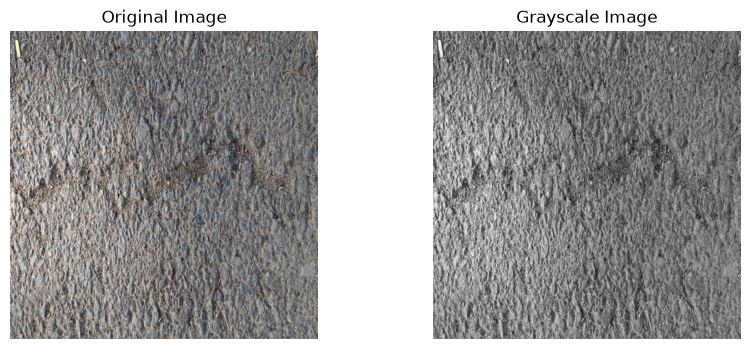

In [82]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [83]:
os.makedirs("results", exist_ok=True)

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray_image, 100, 200)

cv2.imwrite("results/sample_image.png", image)
cv2.imwrite("results/canny_edges.png", edges)

True

In [84]:
mean_brightness = np.mean(gray_image)
print("Mean brightness:", mean_brightness)

Mean brightness: 122.09614656409438


In [85]:
contrast = np.std(gray_image)
print("Contrast:", contrast)

Contrast: 38.01434479318785


In [86]:
dark_ratio = np.mean(gray_image < 50)
print("Dark pixel ratio:", dark_ratio)

Dark pixel ratio: 0.01633250956632653


In [88]:
bright_ratio = np.mean(gray_image > 200)
print("Bright pixel ratio:", bright_ratio)

Bright pixel ratio: 0.02667610012755102


In [89]:
edges = cv2.Canny(gray_image, 100, 200)

print("Edge image shape:", edges.shape)

Edge image shape: (448, 448)


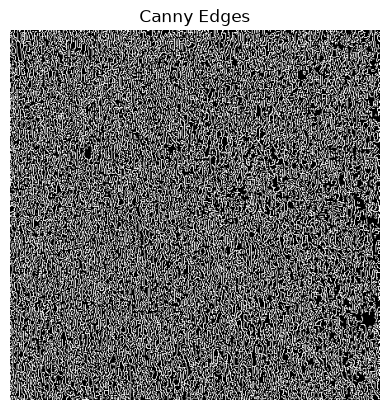

In [90]:
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")
plt.show()

In [91]:
edge_count = np.sum(edges > 0)
print("Edge count:", edge_count)

Edge count: 72585


In [92]:
edge_density = edge_count / edges.size
print("Edge density:", edge_density)

Edge density: 0.3616519850127551


In [93]:
image_names = []
mean_brightness = []
contrast = []
dark_ratio = []
bright_ratio = []
edge_count = []
edge_density = []
labels = []

In [94]:
for folder, label in [(crack_path, "Cracks"), (noncrack_path, "NonCracks")]:
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        img = cv2.imread(path)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        mean_brightness.append(np.mean(gray))
        contrast.append(np.std(gray))

        dark_ratio.append(np.mean(gray < 50))
        bright_ratio.append(np.mean(gray > 200))

        edges = cv2.Canny(gray, 100, 200)
        edge_count.append(np.sum(edges > 0))
        edge_density.append(np.mean(edges > 0))

        image_names.append(file)
        labels.append(label)

In [95]:
print("Images:", len(image_names))
print("Labels:", len(labels))
print("Mean brightness:", len(mean_brightness))
print("Contrast:", len(contrast))
print("Dark ratio:", len(dark_ratio))
print("Bright ratio:", len(bright_ratio))
print("Edge count:", len(edge_count))
print("Edge density:", len(edge_density))

Images: 400
Labels: 400
Mean brightness: 400
Contrast: 400
Dark ratio: 400
Bright ratio: 400
Edge count: 400
Edge density: 400


In [97]:
df = pd.DataFrame({
    "image": image_names,
    "mean_brightness": mean_brightness,
    "contrast": contrast,
    "dark_ratio": dark_ratio,
    "bright_ratio": bright_ratio,
    "edge_count": edge_count,
    "edge_density": edge_density,
    "label": labels
})
print(df.shape)

(400, 8)


In [98]:
print(df.head())
print("\nLabel counts:")
print(df["label"].value_counts())

                                        image  mean_brightness   contrast  \
0  IMG_20180513_164959951_HDR resized_448.jpg       122.096147  38.014345   
1  IMG_20180513_165129852_HDR resized_448.jpg       131.822704  29.319148   
2  IMG_20180513_165150613_HDR resized_448.jpg       121.171217  35.572563   
3  IMG_20180513_165345878_HDR resized_448.jpg       130.117701  32.745086   
4  IMG_20180513_165349788_HDR resized_448.jpg       131.079998  33.199356   

   dark_ratio  bright_ratio  edge_count  edge_density   label  
0    0.016333      0.026676       72585      0.361652  Cracks  
1    0.006741      0.011759       65773      0.327711  Cracks  
2    0.024992      0.020712       63187      0.314827  Cracks  
3    0.008889      0.014917       71668      0.357083  Cracks  
4    0.009741      0.016791       71719      0.357337  Cracks  

Label counts:
label
Cracks       200
NonCracks    200
Name: count, dtype: int64


In [99]:
print(df.describe())

       mean_brightness    contrast  dark_ratio  bright_ratio    edge_count  \
count       400.000000  400.000000  400.000000    400.000000    400.000000   
mean        150.873519   32.033602    0.008732      0.084392  62783.990000   
std          17.756517    9.577624    0.019036      0.064557  13465.291275   
min         110.355299   17.144549    0.000000      0.001440  15945.000000   
25%         134.365630   23.670657    0.000005      0.025903  55198.250000   
50%         152.752220   31.847127    0.001308      0.075472  67399.500000   
75%         166.007000   38.952272    0.010578      0.120380  72714.750000   
max         189.694804   63.906473    0.190709      0.302181  78602.000000   

       edge_density  
count    400.000000  
mean       0.312819  
std        0.067090  
min        0.079445  
25%        0.275023  
50%        0.335815  
75%        0.362298  
max        0.391631  


In [100]:
df.to_csv("results/image_features.csv", index=False)

In [101]:
X = df.drop(columns=["image", "label"])
y = df["label"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 6)
y shape: (400,)


In [102]:
y = y.map({"Cracks": 1, "NonCracks": 0})
print(y.value_counts())
print(y.head())

label
1    200
0    200
Name: count, dtype: int64
0    1
1    1
2    1
3    1
4    1
Name: label, dtype: int64


In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (320, 6)
X_test: (80, 6)
y_train: (320,)
y_test: (80,)


In [104]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (320, 6)
X_test_scaled: (80, 6)


In [105]:
from sklearn.linear_model import LogisticRegression
import time

model = LogisticRegression()

start = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start

print("Training time:", train_time)

Training time: 0.012530326843261719


In [106]:
start = time.time()
y_pred = model.predict(X_test_scaled)
predict_time = time.time() - start

print("Prediction time:", predict_time)

Prediction time: 0.001247406005859375


In [107]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.85
Precision: 0.8181818181818182
Recall: 0.9
F1 Score: 0.8571428571428571


In [108]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[32  8]
 [ 4 36]]


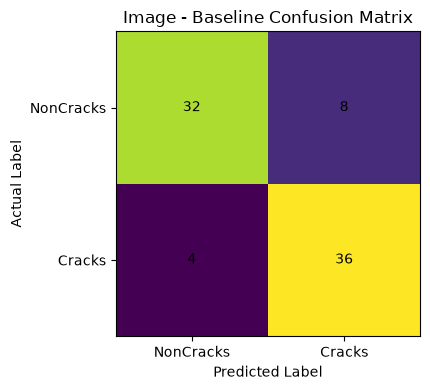

In [109]:
plt.figure(figsize=(5, 4))

plt.imshow(cm, interpolation="nearest")
plt.title("Image - Baseline Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["NonCracks", "Cracks"])
plt.yticks([0, 1], ["NonCracks", "Cracks"])

plt.tight_layout()
plt.savefig("results/image_baseline_confusion_matrix.png")
plt.show()

In [110]:
improved_edge_count = []
improved_edge_density = []

for folder in [crack_path, noncrack_path]:
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        img = cv2.imread(path)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        edges = cv2.Canny(gray, 50, 150)

        improved_edge_count.append(np.sum(edges > 0))
        improved_edge_density.append(np.mean(edges > 0))

print("Images:", len(improved_edge_count))
print("First edge count:", improved_edge_count[0])
print("First edge density:", improved_edge_density[0])

Images: 400
First edge count: 75208
First edge density: 0.37472098214285715


In [111]:
df["improved_edge_count"] = improved_edge_count
df["improved_edge_density"] = improved_edge_density

print(df[["edge_count", "improved_edge_count",
          "edge_density", "improved_edge_density"]].head())

   edge_count  improved_edge_count  edge_density  improved_edge_density
0       72585                75208      0.361652               0.374721
1       65773                74776      0.327711               0.372569
2       63187                72774      0.314827               0.362594
3       71668                75745      0.357083               0.377397
4       71719                75457      0.357337               0.375962


In [112]:
X_improved = df[
    ["mean_brightness", "contrast", "dark_ratio", "bright_ratio",
     "improved_edge_count", "improved_edge_density"]
]

print("X_improved shape:", X_improved.shape)

X_improved shape: (400, 6)


In [113]:
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train_imp:", X_train_imp.shape)
print("X_test_imp:", X_test_imp.shape)

X_train_imp: (320, 6)
X_test_imp: (80, 6)


In [114]:
scaler_imp = StandardScaler()

X_train_imp_scaled = scaler_imp.fit_transform(X_train_imp)
X_test_imp_scaled = scaler_imp.transform(X_test_imp)

print("X_train_imp_scaled:", X_train_imp_scaled.shape)
print("X_test_imp_scaled:", X_test_imp_scaled.shape)

X_train_imp_scaled: (320, 6)
X_test_imp_scaled: (80, 6)


In [115]:
model_imp = LogisticRegression()

start = time.time()
model_imp.fit(X_train_imp_scaled, y_train_imp)
train_time_imp = time.time() - start

print("Improved training time:", train_time_imp)

Improved training time: 0.010531425476074219


In [116]:
start = time.time()
y_pred_imp = model_imp.predict(X_test_imp_scaled)
predict_time_imp = time.time() - start
print("Improved prediction time:", predict_time_imp)

Improved prediction time: 0.0008482933044433594


In [117]:
accuracy_imp = accuracy_score(y_test_imp, y_pred_imp)
precision_imp = precision_score(y_test_imp, y_pred_imp)
recall_imp = recall_score(y_test_imp, y_pred_imp)
f1_imp = f1_score(y_test_imp, y_pred_imp)

print("Improved Accuracy:", accuracy_imp)
print("Improved Precision:", precision_imp)
print("Improved Recall:", recall_imp)
print("Improved F1 Score:", f1_imp)

Improved Accuracy: 0.8625
Improved Precision: 0.8222222222222222
Improved Recall: 0.925
Improved F1 Score: 0.8705882352941177


In [118]:
cm_imp = confusion_matrix(y_test_imp, y_pred_imp)
print(cm_imp)

[[32  8]
 [ 3 37]]


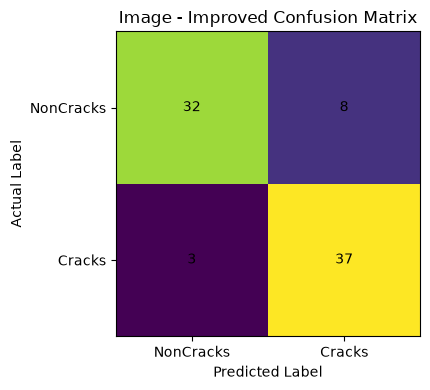

In [119]:
plt.figure(figsize=(5, 4))

plt.imshow(cm_imp, interpolation="nearest")
plt.title("Image - Improved Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(cm_imp.shape[0]):
    for j in range(cm_imp.shape[1]):
        plt.text(j, i, cm_imp[i, j], ha="center", va="center")

plt.xticks([0, 1], ["NonCracks", "Cracks"])
plt.yticks([0, 1], ["NonCracks", "Cracks"])

plt.tight_layout()
plt.savefig("results/image_improved_confusion_matrix.png")
plt.show()

In [120]:
image_results = pd.DataFrame({
    "Approach": ["Baseline", "Improved"],
    "Canny_Threshold": ["100-200", "50-150"],
    "Accuracy": [accuracy, accuracy_imp],
    "Precision": [precision, precision_imp],
    "Recall": [recall, recall_imp],
    "F1_Score": [f1, f1_imp],
    "Training_Time": [train_time, train_time_imp],
    "Prediction_Time": [predict_time, predict_time_imp]
})
image_results.to_csv("results/image_evaluation_results.csv", index=False)
print(image_results)

   Approach Canny_Threshold  Accuracy  Precision  Recall  F1_Score  \
0  Baseline         100-200    0.8500   0.818182   0.900  0.857143   
1  Improved          50-150    0.8625   0.822222   0.925  0.870588   

   Training_Time  Prediction_Time  
0       0.012530         0.001247  
1       0.010531         0.000848  


# Part B - Text Vectorization and Spam Classification

In [121]:
emails = pd.read_csv("emails.csv")
emails

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5167,Email 5168,2,2,2,3,0,0,32,0,0,...,0,0,0,0,0,0,0,0,0,0
5168,Email 5169,35,27,11,2,6,5,151,4,3,...,0,0,0,0,0,0,0,1,0,0
5169,Email 5170,0,0,1,1,0,0,11,0,0,...,0,0,0,0,0,0,0,0,0,1
5170,Email 5171,2,7,1,0,2,1,28,2,0,...,0,0,0,0,0,0,0,1,0,1


In [122]:
print(emails.columns)

Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       ...
       'connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='str', length=3002)


In [123]:
print(emails.dtypes.value_counts())
print("\nNon-numeric columns:")
print(emails.select_dtypes(exclude="number").columns)

int64    3001
str         1
Name: count, dtype: int64

Non-numeric columns:
Index(['Email No.'], dtype='str')


In [124]:
import os

print(os.listdir())

['.ipynb_checkpoints', '202618054_Lab_6.ipynb', 'Crack_and_NonCrack Images', 'emails.csv', 'README.md', 'results']


In [125]:
print(emails["Prediction"].value_counts())

Prediction
0    3672
1    1500
Name: count, dtype: int64


In [126]:
X = emails.drop(columns=["Email No.", "Prediction"])
y = emails["Prediction"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5172, 3000)
y shape: (5172,)


In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4137, 3000)
X_test: (1035, 3000)
y_train: (4137,)
y_test: (1035,)


In [128]:
from sklearn.linear_model import LogisticRegression
import time

model = LogisticRegression(max_iter=1000)

start = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start

print("Training time:", train_time)

Training time: 11.0758798122406


In [129]:
start = time.time()

y_pred = model.predict(X_test)

predict_time = time.time() - start

print("Prediction time:", predict_time)

Prediction time: 0.11544966697692871


In [130]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9826086956521739
Precision: 0.9577922077922078
Recall: 0.9833333333333333
F1 Score: 0.9703947368421053


In [131]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[722  13]
 [  5 295]]


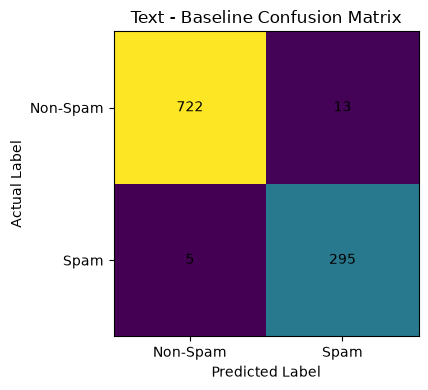

In [132]:
plt.figure(figsize=(5, 4))

plt.imshow(cm, interpolation="nearest")
plt.title("Text - Baseline Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Non-Spam", "Spam"])
plt.yticks([0, 1], ["Non-Spam", "Spam"])

plt.tight_layout()
plt.savefig("results/text_baseline_confusion_matrix.png")
plt.show()

In [133]:
feature_counts = X_train.sum(axis=0)

top_features = feature_counts.sort_values(ascending=False).head(1500).index

X_train_imp = X_train[top_features]
X_test_imp = X_test[top_features]

print("Original features:", X_train.shape[1])
print("Improved features:", X_train_imp.shape[1])

Original features: 3000
Improved features: 1500


In [134]:
model_imp = LogisticRegression(max_iter=1000)

start = time.time()
model_imp.fit(X_train_imp, y_train)
train_time_imp = time.time() - start

print("Improved training time:", train_time_imp)

Improved training time: 3.559307098388672


In [135]:
start = time.time()

y_pred_imp = model_imp.predict(X_test_imp)

predict_time_imp = time.time() - start

print("Improved prediction time:", predict_time_imp)

Improved prediction time: 0.05327129364013672


In [136]:
accuracy_imp = accuracy_score(y_test, y_pred_imp)
precision_imp = precision_score(y_test, y_pred_imp)
recall_imp = recall_score(y_test, y_pred_imp)
f1_imp = f1_score(y_test, y_pred_imp)

print("Improved Accuracy:", accuracy_imp)
print("Improved Precision:", precision_imp)
print("Improved Recall:", recall_imp)
print("Improved F1 Score:", f1_imp)

Improved Accuracy: 0.978743961352657
Improved Precision: 0.954248366013072
Improved Recall: 0.9733333333333334
Improved F1 Score: 0.9636963696369637


In [137]:
cm_imp = confusion_matrix(y_test, y_pred_imp)
print(cm_imp)

[[721  14]
 [  8 292]]


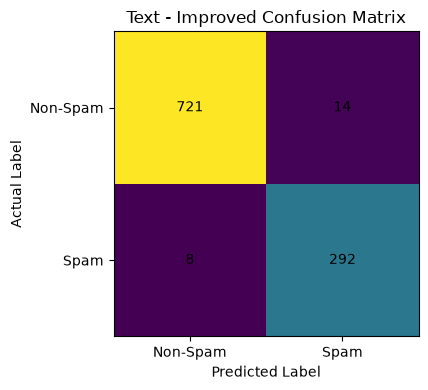

In [138]:
plt.figure(figsize=(5, 4))

plt.imshow(cm_imp, interpolation="nearest")
plt.title("Text - Improved Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(cm_imp.shape[0]):
    for j in range(cm_imp.shape[1]):
        plt.text(j, i, cm_imp[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Non-Spam", "Spam"])
plt.yticks([0, 1], ["Non-Spam", "Spam"])

plt.tight_layout()
plt.savefig("results/text_improved_confusion_matrix.png")
plt.show()

In [139]:
text_results = pd.DataFrame({
    "Approach": ["Baseline", "Improved"],
    "Number_of_Features": [3000, 1500],
    "Accuracy": [accuracy, accuracy_imp],
    "Precision": [precision, precision_imp],
    "Recall": [recall, recall_imp],
    "F1_Score": [f1, f1_imp],
    "Training_Time": [train_time, train_time_imp],
    "Prediction_Time": [predict_time, predict_time_imp]
})

text_results.to_csv("results/text_evaluation_results.csv", index=False)
print(text_results)

   Approach  Number_of_Features  Accuracy  Precision    Recall  F1_Score  \
0  Baseline                3000  0.982609   0.957792  0.983333  0.970395   
1  Improved                1500  0.978744   0.954248  0.973333  0.963696   

   Training_Time  Prediction_Time  
0      11.075880         0.115450  
1       3.559307         0.053271  


In [140]:
text_vectorization_comparison = pd.DataFrame({
    "Representation": ["Original", "Reduced"],
    "Number_of_Features": [X_train.shape[1], X_train_imp.shape[1]],
    "Training_Time": [train_time, train_time_imp],
    "Prediction_Time": [predict_time, predict_time_imp],
    "Accuracy": [accuracy, accuracy_imp],
    "Precision": [precision, precision_imp],
    "Recall": [recall, recall_imp],
    "F1_Score": [f1, f1_imp]
})

text_vectorization_comparison.to_csv(
    "results/text_vectorization_comparison.csv",
    index=False
)
print(text_vectorization_comparison)

  Representation  Number_of_Features  Training_Time  Prediction_Time  \
0       Original                3000      11.075880         0.115450   
1        Reduced                1500       3.559307         0.053271   

   Accuracy  Precision    Recall  F1_Score  
0  0.982609   0.957792  0.983333  0.970395  
1  0.978744   0.954248  0.973333  0.963696  


# **Observations:**

## **Image Dataset:**

- The image dataset contains **400 images**, with **200 Crack** images and **200 Non-Crack** images.
- All images have the same size of **448 × 448 pixels** with 3 color channels.
- The images were converted from BGR to grayscale for feature extraction.
- The grayscale image has pixel values ranging from **0 to 255**.
- Six features were extracted from each image: **mean brightness, contrast, dark pixel ratio, bright pixel ratio, edge count, and edge density**.
- Canny edge detection was used to identify edges in the images.
- The baseline Logistic Regression model achieved:
  - Accuracy = **85.00%**
  - Precision = **81.82%**
  - Recall = **90.00%**
  - F1 Score = **85.71%**
- The Canny thresholds were changed from **(100, 200)** to **(50, 150)**.
- After the change, the accuracy increased from **85.00% to 86.25%** and the F1 score increased from **85.71% to 87.06%**.
- The computation time changed only slightly, so the lower Canny thresholds improved the classification performance without a major increase in computation time.

## **Text Dataset:**

- The email dataset contains **5,172 emails** and **3,000 word-count features**.
- There are **3,672 emails in class 0** and **1,500 emails in class 1**.
- The `Email No.` column was removed because it is only an identifier, while `Prediction` was used as the target variable.
- The dataset provided in `emails.csv` was already in a word-count feature representation, so the 3,000 word columns were used as the input features.
- The baseline Logistic Regression model achieved:
  - Accuracy = **98.26%**
  - Precision = **95.78%**
  - Recall = **98.33%**
  - F1 Score = **97.04%**
- The baseline model took approximately **11.08 seconds** for training and **0.115 seconds** for prediction.
- The number of features was reduced from **3,000 to 1,500** by selecting the most frequent features.
- The reduced-feature model decreased training time from **11.08 seconds to 3.56 seconds** and prediction time from **0.115 seconds to 0.053 seconds**.
- However, accuracy decreased slightly from **98.26% to 97.87%**, and F1 score decreased from **97.04% to 96.37%**.
- Therefore, reducing the number of features reduced computation time but caused a small decrease in classification performance.